## **Assignment 4**: Clustering using Hierarchical Clustering

## Problem Statement:
Perform hierarchical clustering to group vehicles based on their specifications using the **Agglomerative algorithm**. Explore different linkage strategies — **single**, **complete**, and **average** — and visualize the clusters using **dendrograms**.

#### Data Loading and Importing Libraries

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

In [2]:
df = pd.read_csv('Datasets/cars_clustering.csv')

#### EDA

In [3]:
# Preview the data

df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.36,0,21.5,1.8,140,101.2,67.3,172.4,2.639,13.2,28,2.828,0
1,Acura,TL,39.384,19.875,0,28.4,3.2,225,108.1,70.3,192.9,3.517,17.2,25,3.673,0
2,Acura,CL,14.114,18.225,0,$null$,3.2,225,106.9,70.6,192,3.47,17.2,26,2.647,0
3,Acura,RL,8.588,29.725,0,42,3.5,210,114.6,71.4,196.6,3.85,18,22,2.15,0
4,Audi,A4,20.397,22.255,0,23.99,1.8,150,102.6,68.2,178,2.998,16.4,27,3.015,0


In [4]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The dataset has 159 rows and 16 columns


In [5]:
# Summary of dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   manufact   157 non-null    object
 1   model      159 non-null    object
 2   sales      159 non-null    object
 3   resale     159 non-null    object
 4   type       159 non-null    object
 5   price      159 non-null    object
 6   engine_s   159 non-null    object
 7   horsepow   159 non-null    object
 8   wheelbas   159 non-null    object
 9   width      159 non-null    object
 10  length     159 non-null    object
 11  curb_wgt   159 non-null    object
 12  fuel_cap   159 non-null    object
 13  mpg        159 non-null    object
 14  lnsales    159 non-null    object
 15  partition  159 non-null    int64 
dtypes: int64(1), object(15)
memory usage: 20.0+ KB


In [6]:
df.describe()

,partition
count,159.000000
mean,0.012579
std,0.111799
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [7]:
df.isnull().sum()

manufact     2
model        0
sales        0
resale       0
type         0
price        0
engine_s     0
horsepow     0
wheelbas     0
width        0
length       0
curb_wgt     0
fuel_cap     0
mpg          0
lnsales      0
partition    0
dtype: int64

In [8]:
df.replace('$null$', np.nan, inplace=True)


In [9]:
df.isnull().sum()

manufact      2
model         0
sales         2
resale       38
type          2
price         2
engine_s      1
horsepow      1
wheelbas      1
width         1
length        1
curb_wgt      2
fuel_cap      1
mpg           3
lnsales       2
partition     0
dtype: int64

In [10]:
numeric_cols = [
    "sales", "resale", "price", "engine_s", "horsepow", "wheelbas",
    "width", "length", "curb_wgt", "fuel_cap", "mpg", "lnsales"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [12]:
df_cluster = df[numeric_cols].copy()

In [13]:
df_cluster.reset_index(drop=True, inplace=True)

#### Model

In [14]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

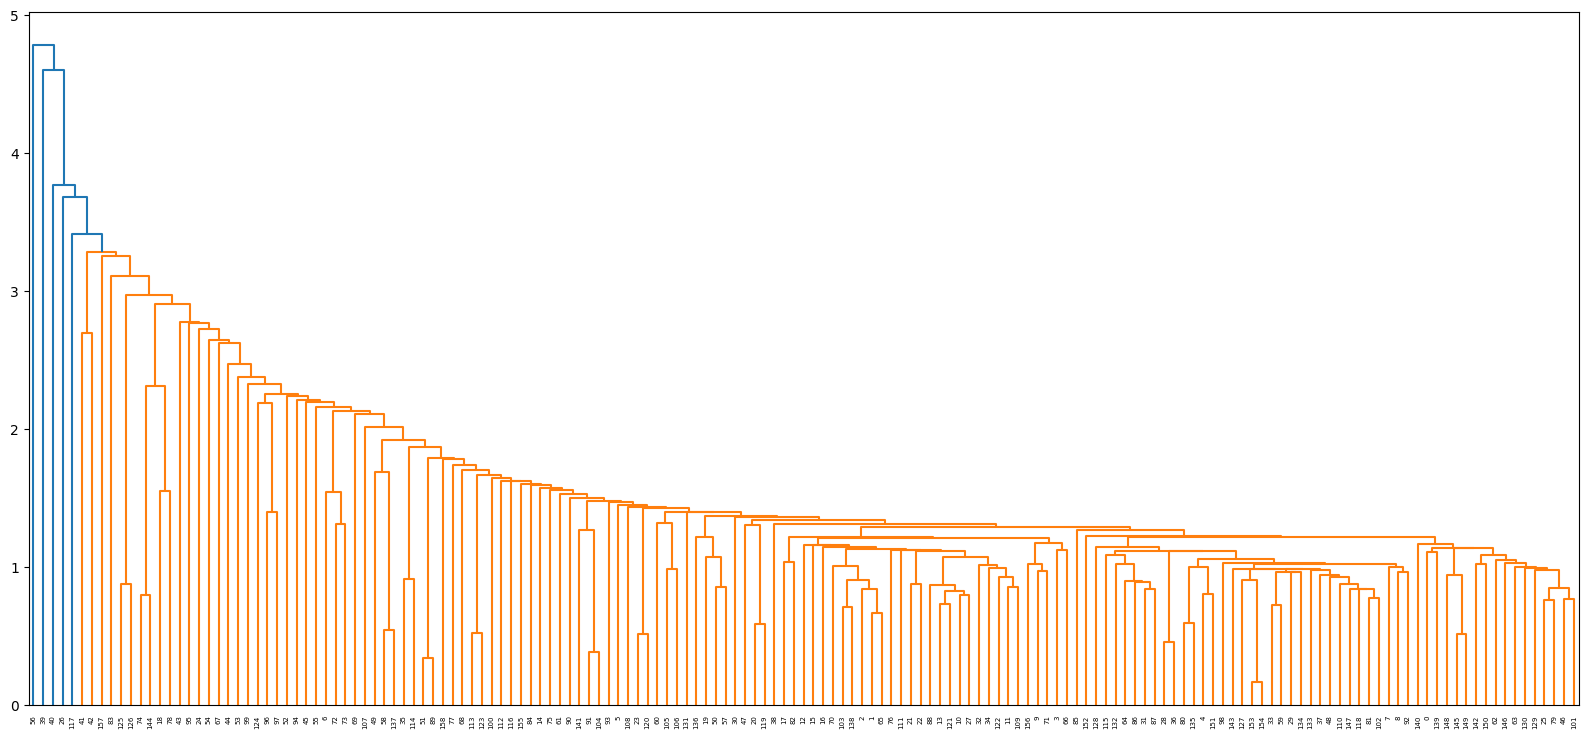

In [21]:
plt.figure(figsize=(20,9))
z = linkage(df_scaled, method ="single")
dendrogram(z)
plt.show()

In [15]:
def plot_dendrograms(data, methods=["single", "complete", "average"]):
    plt.figure(figsize=(20, 5 * len(methods)))

    for i, method in enumerate(methods):
        plt.subplot(len(methods), 1, i + 1)
        Z = linkage(data, method=method)
        dendrogram(Z)
        plt.title(f"Hierarchical Clustering Dendrogram ({method.title()} Linkage)")
        plt.xlabel("Sample Index")
        plt.ylabel("Distance")

    plt.tight_layout()
    plt.show()

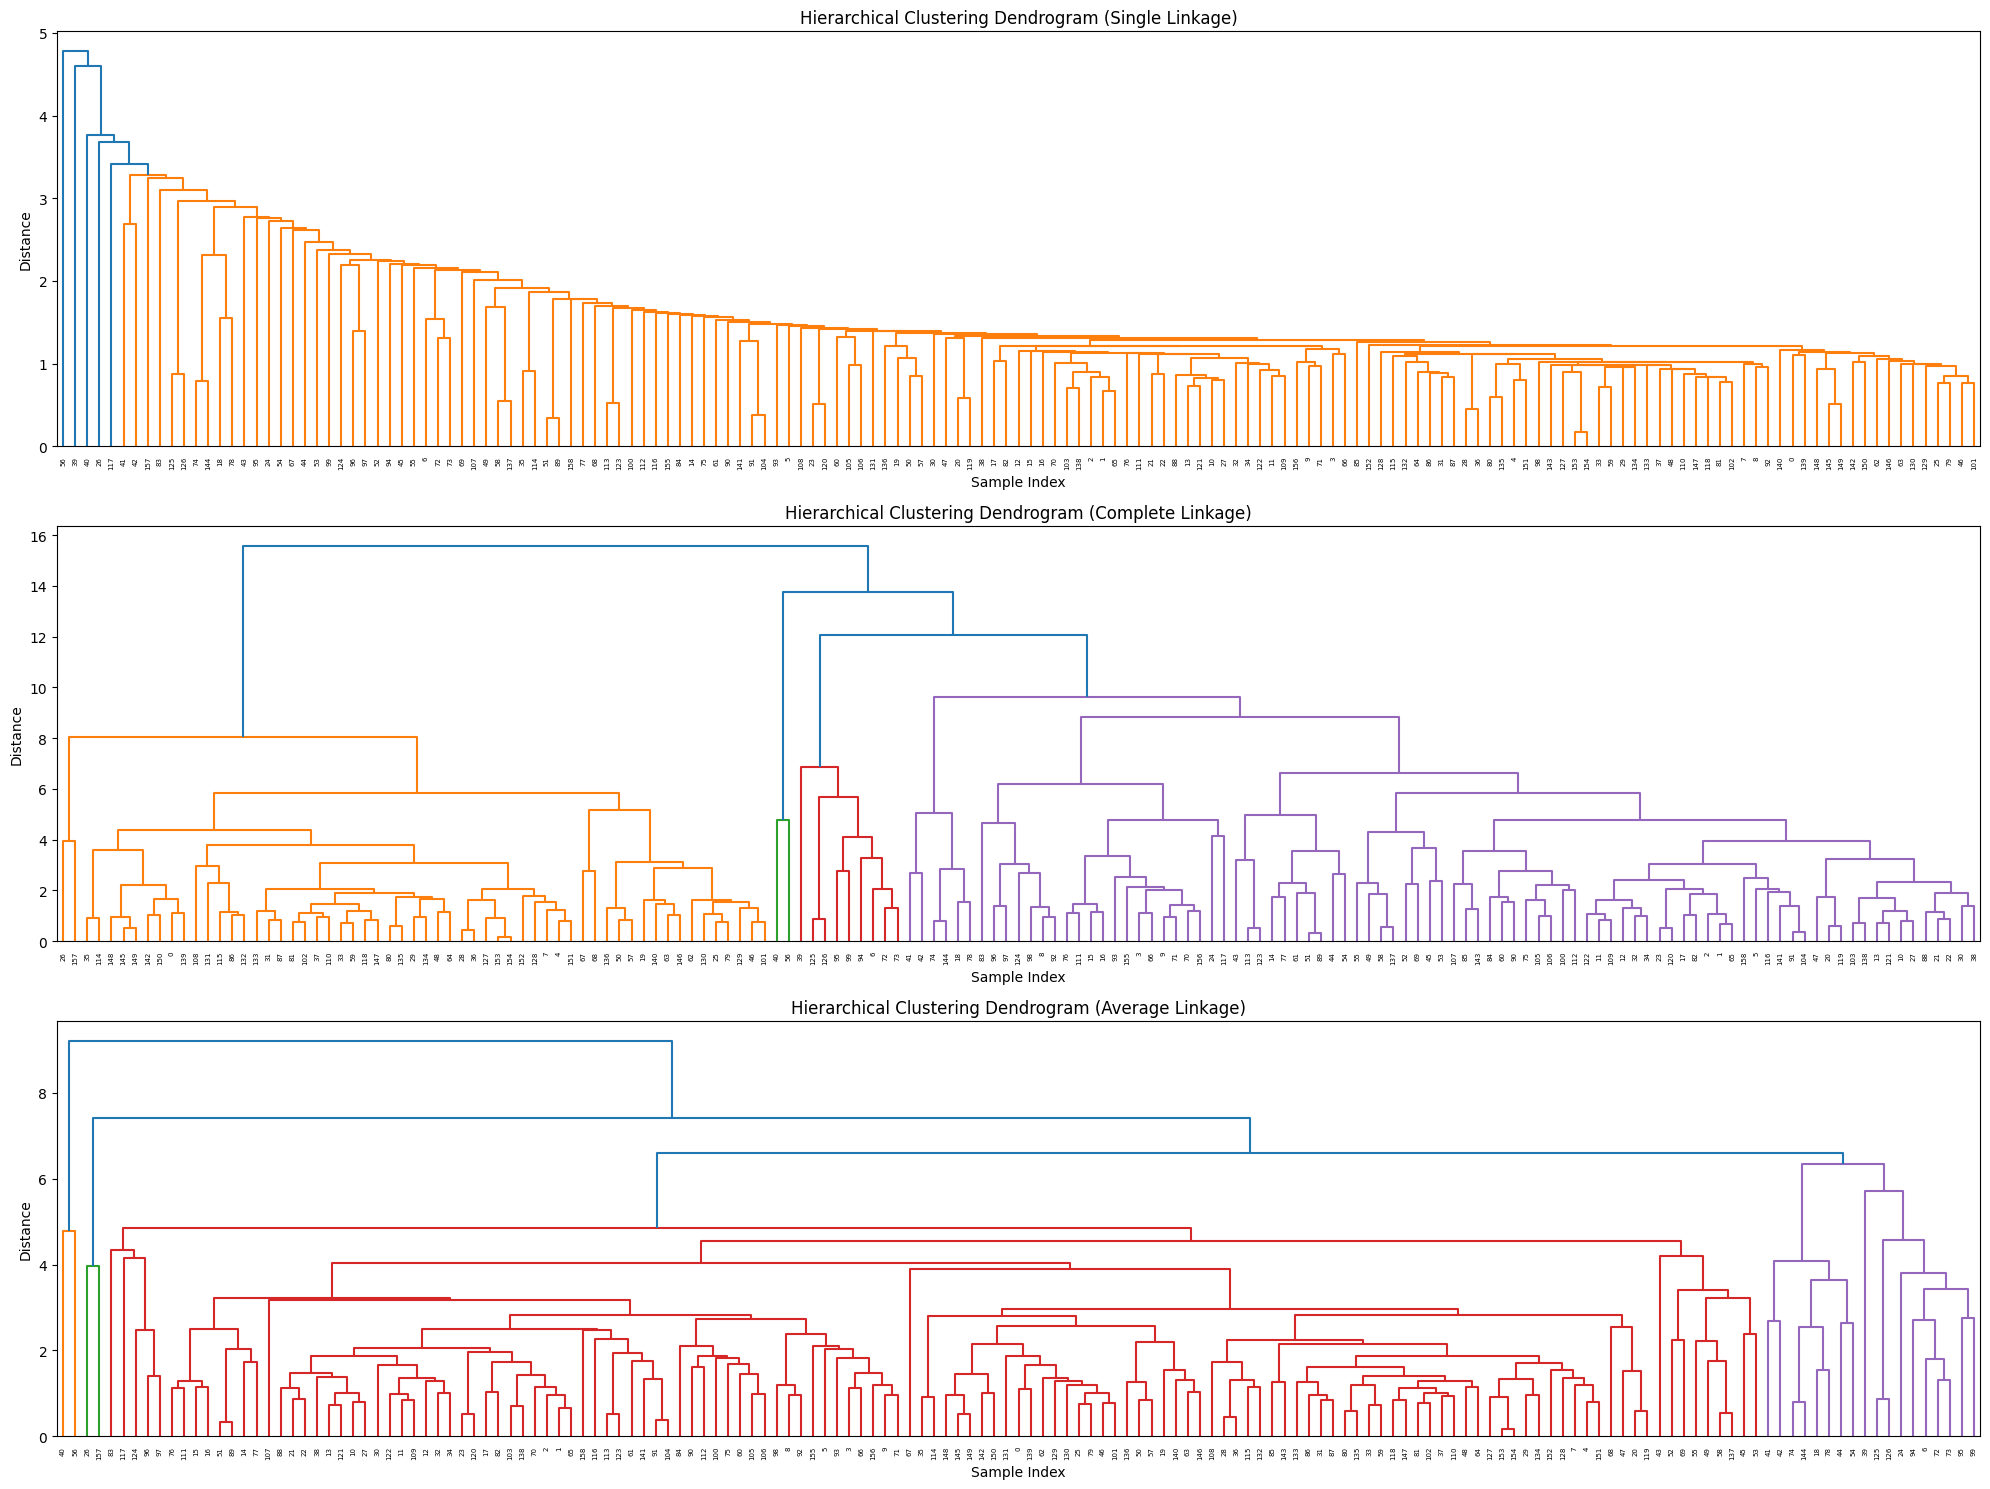

In [16]:
plot_dendrograms(df_scaled)

In [17]:
agg = AgglomerativeClustering(n_clusters=4, linkage='average')
clusters = agg.fit_predict(df_scaled)

In [18]:
df_cluster["cluster"] = clusters

In [19]:
df_cluster.groupby("cluster").mean()

,sales,resale,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales
cluster,,,,,,,,,,,,
0,21.404111,38.341056,53.587944,4.727778,278.277778,110.433333,74.466667,192.027778,4.209778,23.966667,18.388889,2.058000
1,52.323480,16.217752,24.214089,2.828905,173.864234,106.741022,70.676350,186.409781,3.279099,17.087737,24.502920,3.420254
2,63.098000,6.646000,15.367500,1.250000,65.500000,99.700000,65.250000,162.200000,2.413500,11.100000,45.500000,3.719500
3,383.811000,15.067500,23.197500,4.900000,225.000000,138.600000,79.200000,224.350000,4.355500,25.550000,17.500000,5.859000
